# Checkpoint 3: Alternative Model — Random Forest Regressor
**Trenton McDonald and Fahed (Dan) Geravi**

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [14]:
# Load and parse lap data
file_path = Path("../data/lap_times_2023_3_5343.json")
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []
for driver_entry in data["laps"]:
    driver_name = driver_entry.get("FullName")
    for lap_entry in driver_entry.get("Laps", []):
        rows.append({
            "Driver": driver_name,
            "Lap": lap_entry.get("Lap"),
            "LapTime": lap_entry.get("LapTime"),
            "LapSpeed": lap_entry.get("LapSpeed"),
            "RunningPos": lap_entry.get("RunningPos")
        })

df = pd.DataFrame(rows)
print("Raw shape:", df.shape)

Raw shape: (2575, 5)


In [15]:
# Clean data (same preprocessing as baseline)
for col in ["Lap", "LapTime", "LapSpeed", "RunningPos"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Lap", "LapTime", "LapSpeed", "RunningPos"]).copy()
df = df[df["Lap"] > 0].copy()
df = df[(df["LapTime"] < 100) & (df["LapSpeed"] > 100)].copy()
df = df.sort_values(["Driver", "Lap"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (1248, 5)


,Driver,Lap,LapTime,LapSpeed,RunningPos
0,Ben Rhodes,1,53.211,169.138,19
1,Ben Rhodes,2,52.852,170.287,17
2,Ben Rhodes,7,85.951,104.711,16
3,Ben Rhodes,11,51.798,173.752,16
4,Ben Rhodes,12,49.093,183.326,20


In [16]:
# Define features and target (same as baseline)
X = df[["Lap", "LapTime", "LapSpeed"]]
y = df["RunningPos"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 998
Testing rows: 250


## Hyperparameter Tuning via Grid Search with 5-Fold Cross-Validation

In [17]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best CV R²: 0.4396


In [18]:
# Use best model
model = grid_search.best_estimator_

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Training Metrics")
print(f"  R²:   {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print()
print("Testing Metrics")
print(f"  R²:   {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")

Training Metrics
  R²:   0.7554
  RMSE: 4.7231
  MAE:  3.6098

Testing Metrics
  R²:   0.4426
  RMSE: 7.5669
  MAE:  5.8232


## Cross-Validation on Full Dataset

In [19]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("5-Fold CV R² scores:", cv_scores)
print(f"Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold CV R² scores: [0.35586295 0.34060785 0.24828891 0.35383033 0.42030489]
Mean CV R²: 0.3438 ± 0.0552


## Feature Importances

    Feature  Importance
1   LapTime    0.343131
2  LapSpeed    0.333275
0       Lap    0.323594


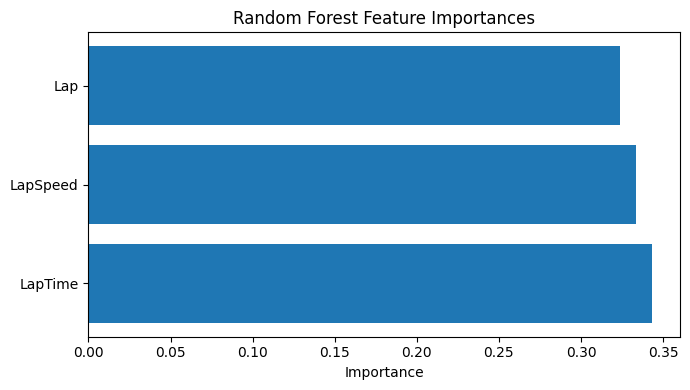

In [20]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feat_imp)

plt.figure(figsize=(7, 4))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.savefig(figures_dir / "rf_feature_importance.png", dpi=300)
plt.show()

## Predicted vs Actual

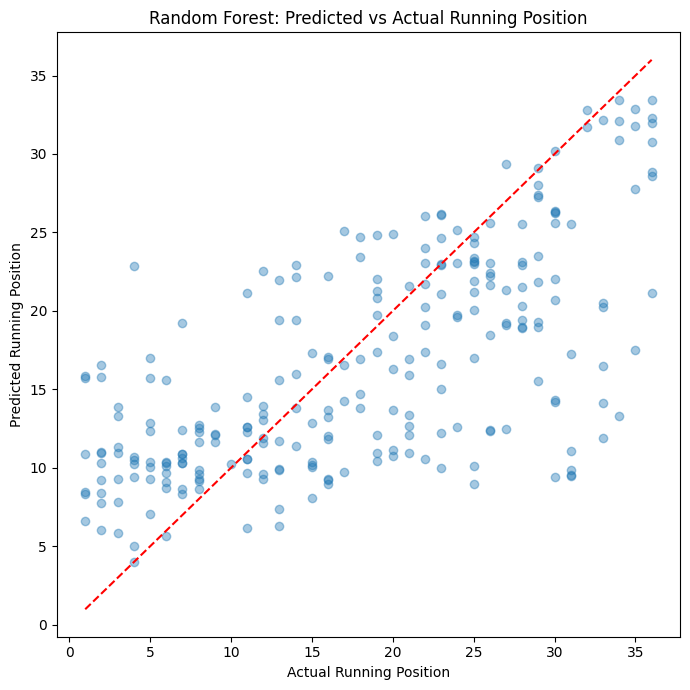

In [21]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_test_pred, alpha=0.4)
mn = min(y_test.min(), y_test_pred.min())
mx = max(y_test.max(), y_test_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Actual Running Position")
plt.ylabel("Predicted Running Position")
plt.title("Random Forest: Predicted vs Actual Running Position")
plt.tight_layout()
plt.savefig(figures_dir / "rf_predicted_vs_actual.png", dpi=300)
plt.show()

## Residual Plot

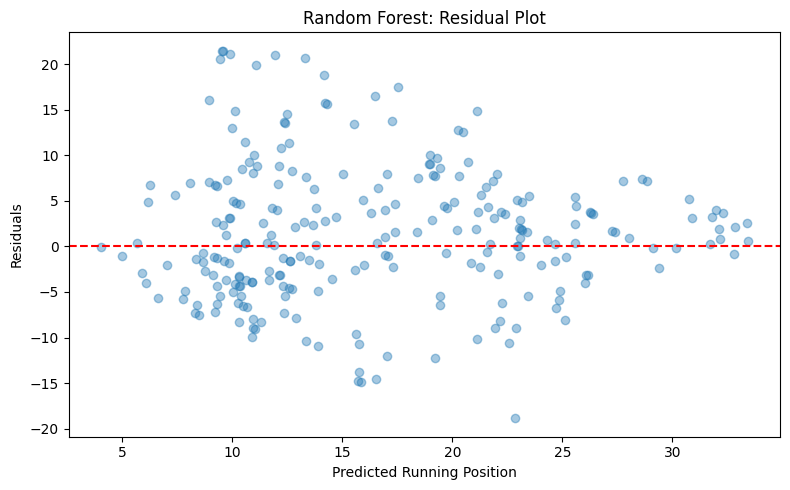

In [22]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.4)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Running Position")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Plot")
plt.tight_layout()
plt.savefig(figures_dir / "rf_residual_plot.png", dpi=300)
plt.show()

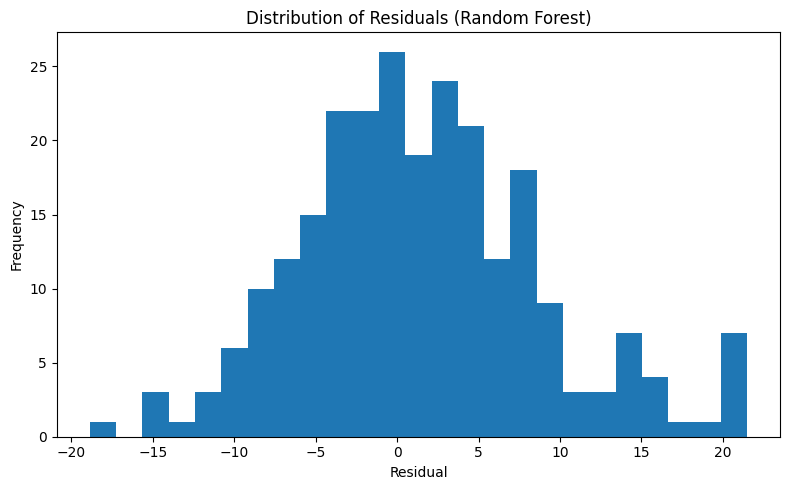

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals (Random Forest)")
plt.tight_layout()
plt.savefig(figures_dir / "rf_residual_histogram.png", dpi=300)
plt.show()

## Summary Comparison

In [24]:
print("=" * 55)
print(f"{'Metric':<20} {'Linear Reg':>15} {'Random Forest':>15}")
print("=" * 55)
print(f"{'Train R²':<20} {'0.0594':>15} {train_r2:>15.4f}")
print(f"{'Test R²':<20} {'0.0350':>15} {test_r2:>15.4f}")
print(f"{'Train RMSE':<20} {'9.2628':>15} {train_rmse:>15.4f}")
print(f"{'Test RMSE':<20} {'9.9565':>15} {test_rmse:>15.4f}")
print(f"{'Train MAE':<20} {'7.9375':>15} {train_mae:>15.4f}")
print(f"{'Test MAE':<20} {'8.7068':>15} {test_mae:>15.4f}")
print("=" * 55)

Metric                    Linear Reg   Random Forest
Train R²                      0.0594          0.7554
Test R²                       0.0350          0.4426
Train RMSE                    9.2628          4.7231
Test RMSE                     9.9565          7.5669
Train MAE                     7.9375          3.6098
Test MAE                      8.7068          5.8232
